# LLM Authorship Detection with BERT
Classificar texto como gerado por: **Human · Google · Meta · OpenAI · Anthropic**

Estrutura do notebook:
1. Setup & Config
2. **Parte A — Zero-shot** (sem treino nos nossos dados)
3. **Parte B — Fine-tuning** (com subconjunto configurável do train.csv)

## 0 · Setup

In [1]:
# !pip install transformers torch pandas scikit-learn

In [20]:
import random
import numpy as np
import pandas as pd
import torch
from torch.utils.data import Dataset, DataLoader, random_split
from torch.optim import AdamW
from transformers import (
    BertTokenizer,
    BertForSequenceClassification,
    pipeline,
    get_linear_schedule_with_warmup,
    AutoModelForSequenceClassification,
    DistilBertTokenizer
)
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Reproducibilidade
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

print("Imports OK")

Imports OK


In [21]:
# ── Device ────────────────────────────────────────────────────────────────────
if torch.cuda.is_available():
    DEVICE = torch.device("cuda")
elif torch.backends.mps.is_available():
    DEVICE = torch.device("mps")   # Apple Silicon
else:
    DEVICE = torch.device("cpu")

print(f"Device: {DEVICE}")

Device: cpu


In [22]:
# ── Labels ────────────────────────────────────────────────────────────────────
LABELS    = ["Human", "Google", "Meta", "OpenAI", "Anthropic"]
LABEL2IDX = {l: i for i, l in enumerate(LABELS)}
IDX2LABEL = {i: l for l, i in LABEL2IDX.items()}
NUM_CLASSES = len(LABELS)

# ── Ficheiros ─────────────────────────────────────────────────────────────────
TRAIN_PATH = "data/train.csv"
TEST_PATH  = "data/test.csv"

---
## Parte A · Zero-Shot (sem fine-tuning)

Usamos um modelo de **zero-shot classification** (BART-MNLI) que nunca viu os nossos dados.
Dado um texto e uma lista de labels candidatos, o modelo devolve uma probabilidade para cada um.

> Útil como **baseline**: se conseguirmos melhorar isto com fine-tuning, o esforço valeu a pena.

In [5]:
# Carrega o pipeline de zero-shot (faz download automático ~1.6 GB)
zs_classifier = pipeline(
    "zero-shot-classification",
    model="facebook/bart-large-mnli",
    device=0 if DEVICE.type == "cuda" else -1,  # -1 = CPU
)
print("Zero-shot pipeline pronto.")

Loading weights:   0%|          | 0/515 [00:00<?, ?it/s]

Zero-shot pipeline pronto.


In [6]:
# ── Teste rápido num exemplo ──────────────────────────────────────────────────
exemplo = "As a large language model, I strive to be helpful and harmless."

resultado = zs_classifier(
    exemplo,
    candidate_labels=LABELS,
    hypothesis_template="This text was written by {}.",
)

print(f"Texto  : {exemplo}\n")
for label, score in zip(resultado["labels"], resultado["scores"]):
    print(f"  {label:<12} {score:.3f}")

Texto  : As a large language model, I strive to be helpful and harmless.

  Meta         0.485
  Anthropic    0.234
  Human        0.194
  OpenAI       0.052
  Google       0.035


In [7]:
# ── Avaliação zero-shot no test.csv ──────────────────────────────────────────
# Configura quantos exemplos de teste usar (pode ser pesado com muitos)
ZS_TEST_SUBSET = None

df_test = pd.read_csv(TEST_PATH, sep=";")
if ZS_TEST_SUBSET:
    df_test = df_test.sample(ZS_TEST_SUBSET, random_state=SEED).reset_index(drop=True)

print(f"Avaliar {len(df_test)} exemplos no modo zero-shot...")

zs_preds  = []
zs_labels = []

for i, row in df_test.iterrows():
    res = zs_classifier(
        str(row["Text"]),
        candidate_labels=LABELS,
        hypothesis_template="This text was written by {}.",
    )
    zs_preds.append(res["labels"][0])   # label com maior score
    zs_labels.append(row["Label"])
    if (i + 1) % 50 == 0:
        print(f"  {i+1}/{len(df_test)}")

print("Done.")

Avaliar 314 exemplos no modo zero-shot...


KeyboardInterrupt: 

Zero-Shot Accuracy: 0.1778

              precision    recall  f1-score   support

       Human       0.33      0.05      0.09        40
      Google       0.00      0.00      0.00        33
        Meta       0.50      0.07      0.12        86
      OpenAI       0.15      0.91      0.26        35
   Anthropic       0.00      0.00      0.00        31

    accuracy                           0.18       225
   macro avg       0.20      0.21      0.09       225
weighted avg       0.27      0.18      0.10       225



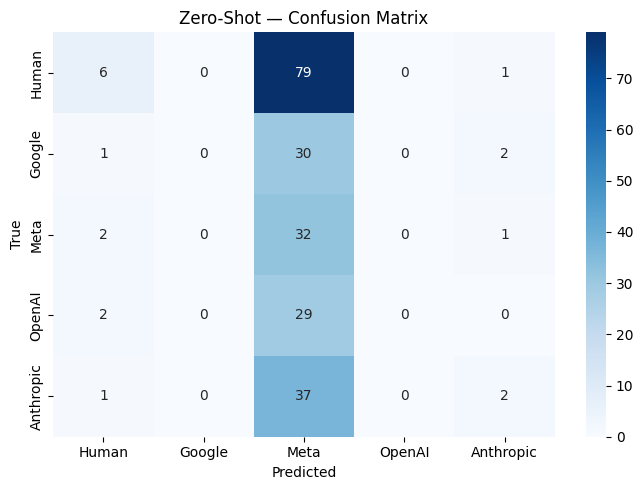

In [ ]:
# ── Resultados zero-shot ──────────────────────────────────────────────────────
zs_acc = accuracy_score(zs_labels, zs_preds)
print(f"Zero-Shot Accuracy: {zs_acc:.4f}\n")
print(classification_report(zs_labels, zs_preds, target_names=LABELS, zero_division=0))

# Matriz de confusão
cm = confusion_matrix(zs_labels, zs_preds, labels=LABELS)
plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt="d", xticklabels=LABELS, yticklabels=LABELS, cmap="Blues")
plt.title("Zero-Shot — Confusion Matrix")
plt.ylabel("True")
plt.xlabel("Predicted")
plt.tight_layout()
plt.show()

---
## Parte B · Fine-tuning BERT

Agora treinamos o BERT com os nossos dados. Os parâmetros principais estão todos na célula de config abaixo.

In [41]:
# ╔══════════════════════════════════════════════════════╗
# ║                 CONFIGURAÇÃO                         ║
# ╚══════════════════════════════════════════════════════╝
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

MODEL_NAME   = "distilbert-base-cased"  # checkpoint pré-treinado
MAX_LEN      = 192    # tokens por texto (256 é mais rigoroso mas mais lento)
BATCH_SIZE   = 16     # reduz para 8 se ficares sem memória
EPOCHS       = 4      # 2-4 épocas costuma ser suficiente para fine-tuning
LR           = 2e-5   # learning rate standard para BERT
VAL_PERC     = 0.8    # 80% treino, 20% validação

# Subconjunto de treino — ajusta conforme o tempo disponível
#   None  → usa todos os dados de train.csv
#   1000  → usa apenas 1000 exemplos de treino
TRAIN_SUBSET = 2000
TEST_SUBSET  = None   # None = usa todo o test.csv

### B1 · Carregar e tokenizar os dados

In [42]:
df_train_full = pd.read_csv(TRAIN_PATH, sep=";")
df_test_full  = pd.read_csv(TEST_PATH, sep=";")
df_subm2 = pd.read_csv("data/subm2_test.csv", sep=";")

if TRAIN_SUBSET:
    df_train_full = df_train_full.sample(TRAIN_SUBSET, random_state=SEED).reset_index(drop=True)
if TEST_SUBSET:
    df_test_full  = df_test_full.sample(TEST_SUBSET,  random_state=SEED).reset_index(drop=True)

print(f"Treino  : {len(df_train_full)} exemplos")
print(f"Teste   : {len(df_test_full)} exemplos")
print()
print(df_train_full["Label"].value_counts())

Treino  : 2000 exemplos
Teste   : 314 exemplos

Label
Meta         433
OpenAI       425
Human        384
Anthropic    381
Google       377
Name: count, dtype: int64


In [43]:
tokenizer = DistilBertTokenizer.from_pretrained(MODEL_NAME)
print(f"Tokenizer carregado: {MODEL_NAME}")

Tokenizer carregado: distilbert-base-cased


In [44]:
class LLMAuthorDataset(Dataset):
    def __init__(self, df, tokenizer, max_len):
        self.texts  = df["Text"].tolist()
        self.labels = [LABEL2IDX[l] for l in df["Label"].tolist()]
        self.tokenizer = tokenizer
        self.max_len   = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        enc = self.tokenizer(
            str(self.texts[idx]),
            padding="max_length",
            truncation=True,
            max_length=self.max_len,
            return_tensors="pt",
        )
        return {
            "input_ids"      : enc["input_ids"].squeeze(0),
            "attention_mask" : enc["attention_mask"].squeeze(0),
            #"token_type_ids" : enc["token_type_ids"].squeeze(0),
            "label"          : torch.tensor(self.labels[idx], dtype=torch.long),
        }

In [45]:
full_train_ds = LLMAuthorDataset(df_train_full, tokenizer, MAX_LEN)
test_ds       = LLMAuthorDataset(df_test_full,  tokenizer, MAX_LEN)
subm2_ds = LLMAuthorDataset(df_subm2, tokenizer, MAX_LEN)

train_size = int(VAL_PERC * len(full_train_ds))
val_size   = len(full_train_ds) - train_size
train_ds, val_ds = random_split(
    full_train_ds, [train_size, val_size],
    generator=torch.Generator().manual_seed(SEED)
)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE)
subm2_loader = DataLoader(subm2_ds,  batch_size=BATCH_SIZE)

print(f"Treino : {len(train_ds)}  |  Val : {len(val_ds)}  |  Teste : {len(test_ds)}")
print(f"Batches por época: {len(train_loader)}")

Treino : 1600  |  Val : 400  |  Teste : 314
Batches por época: 100


### B2 · Modelo, Optimizer e Scheduler

In [46]:
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=NUM_CLASSES,
    output_attentions=False,
    output_hidden_states=False,
    id2label=IDX2LABEL,
    label2id=LABEL2IDX,
)
model.to(DEVICE)

n_params = sum(p.numel() for p in model.parameters()) / 1e6
print(f"Modelo: {MODEL_NAME} — {n_params:.1f}M parâmetros")

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-cased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
classifier.bias         | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.bias     | MISSING    | 
pre_classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Modelo: distilbert-base-cased — 65.8M parâmetros


In [47]:
optimizer = AdamW(model.parameters(), lr=LR, eps=1e-8)

total_steps   = len(train_loader) * EPOCHS
warmup_steps  = int(0.1 * total_steps)

scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=warmup_steps,
    num_training_steps=total_steps,
)

print(f"Total steps: {total_steps}  |  Warmup: {warmup_steps}")

Total steps: 400  |  Warmup: 40


### B3 · Treino e Validação

In [48]:
def train_epoch(model, loader, optimizer, scheduler):
    model.train()
    total_loss = 0
    correct = 0
    total   = 0

    for step, batch in enumerate(loader):
        input_ids      = batch["input_ids"].to(DEVICE)
        attention_mask = batch["attention_mask"].to(DEVICE)
        labels         = batch["label"].to(DEVICE)

        outputs = model(
            input_ids=input_ids,
            attention_mask=attention_mask,
            labels=labels,
        )

        loss = outputs.loss
        total_loss += loss.item()

        preds = outputs.logits.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total   += labels.size(0)

        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        scheduler.step()

        if (step + 1) % 20 == 0:
            print(f"  Step {step+1}/{len(loader)} | Loss: {loss.item():.4f}")

    return total_loss / len(loader), correct / total


def evaluate_loader(model, loader):
    model.eval()
    total_loss = 0
    all_preds, all_labels = [], []

    with torch.no_grad():
        for batch in loader:
            input_ids      = batch["input_ids"].to(DEVICE)
            attention_mask = batch["attention_mask"].to(DEVICE)
            #token_type_ids = batch["token_type_ids"].to(DEVICE)
            labels         = batch["label"].to(DEVICE)

            outputs = model(
                input_ids=input_ids,
                attention_mask=attention_mask,
                #token_type_ids=token_type_ids,
                labels=labels,
            )

            total_loss += outputs.loss.item()
            preds = outputs.logits.argmax(dim=1).cpu().numpy()
            all_preds.extend(preds)
            all_labels.extend(labels.cpu().numpy())

    avg_loss = total_loss / len(loader)
    acc      = accuracy_score(all_labels, all_preds)
    return avg_loss, acc, all_labels, all_preds

In [49]:
# ── Loop de treino ────────────────────────────────────────────────────────────
history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}

print("=" * 55)
print(" Fine-tuning BERT")
print("=" * 55)

for epoch in range(1, EPOCHS + 1):
    print(f"\n── Época {epoch}/{EPOCHS} ──")

    tr_loss, tr_acc = train_epoch(model, train_loader, optimizer, scheduler)
    vl_loss, vl_acc, _, _ = evaluate_loader(model, val_loader)

    history["train_loss"].append(tr_loss)
    history["train_acc"].append(tr_acc)
    history["val_loss"].append(vl_loss)
    history["val_acc"].append(vl_acc)

    print(f"  Train  →  Loss: {tr_loss:.4f}  Acc: {tr_acc:.4f}")
    print(f"  Val    →  Loss: {vl_loss:.4f}  Acc: {vl_acc:.4f}")

print("\nTreino concluído.")

 Fine-tuning BERT

── Época 1/4 ──
  Step 20/100 | Loss: 1.6436
  Step 40/100 | Loss: 1.6035
  Step 60/100 | Loss: 1.3467
  Step 80/100 | Loss: 1.3773
  Step 100/100 | Loss: 0.9904
  Train  →  Loss: 1.4440  Acc: 0.3638
  Val    →  Loss: 1.0984  Acc: 0.6700

── Época 2/4 ──
  Step 20/100 | Loss: 0.9673
  Step 40/100 | Loss: 0.9969
  Step 60/100 | Loss: 1.0109
  Step 80/100 | Loss: 0.6386
  Step 100/100 | Loss: 0.8248
  Train  →  Loss: 0.8859  Acc: 0.7025
  Val    →  Loss: 0.7474  Acc: 0.7400

── Época 3/4 ──
  Step 20/100 | Loss: 0.7438
  Step 40/100 | Loss: 0.4928
  Step 60/100 | Loss: 0.5246
  Step 80/100 | Loss: 0.4412
  Step 100/100 | Loss: 0.4010
  Train  →  Loss: 0.6092  Acc: 0.7925
  Val    →  Loss: 0.6498  Acc: 0.7700

── Época 4/4 ──
  Step 20/100 | Loss: 0.5803
  Step 40/100 | Loss: 0.3296
  Step 60/100 | Loss: 0.4020
  Step 80/100 | Loss: 0.6446
  Step 100/100 | Loss: 0.3481
  Train  →  Loss: 0.4537  Acc: 0.8519
  Val    →  Loss: 0.5714  Acc: 0.7875

Treino concluído.


### B4 · Curvas de Loss e Accuracy

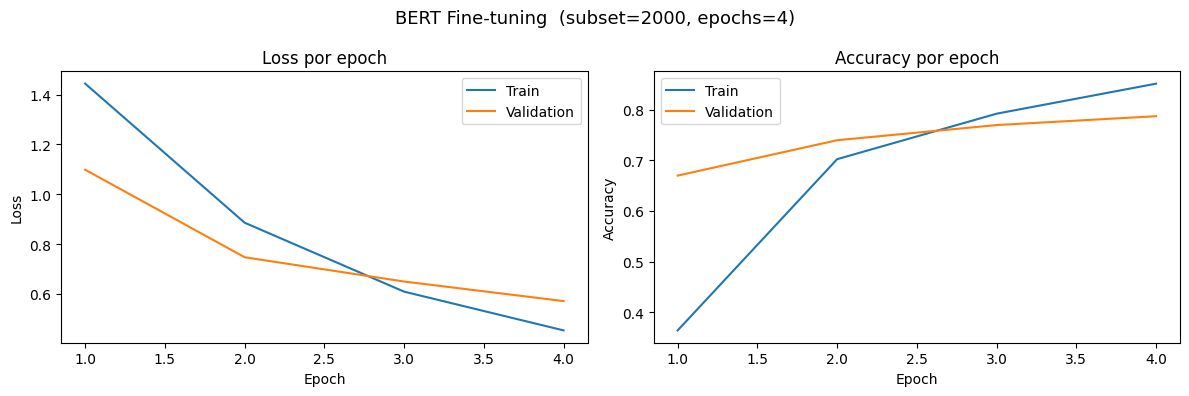

In [50]:
epochs_range = range(1, EPOCHS + 1)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(epochs_range, history["train_loss"], label="Train")
axes[0].plot(epochs_range, history["val_loss"],   label="Validation")
axes[0].set_title("Loss por epoch")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].legend()

axes[1].plot(epochs_range, history["train_acc"], label="Train")
axes[1].plot(epochs_range, history["val_acc"],   label="Validation")
axes[1].set_title("Accuracy por epoch")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].legend()

plt.suptitle(f"BERT Fine-tuning  (subset={TRAIN_SUBSET}, epochs={EPOCHS})", fontsize=13)
plt.tight_layout()
plt.show()

### B5 · Avaliação no conjunto de teste

In [51]:
_, test_acc, test_labels, test_preds = evaluate_loader(model, test_loader)

print(f"Test Accuracy: {test_acc:.4f}\n")
print(classification_report(
    test_labels, test_preds,
    target_names=LABELS,
    zero_division=0
))

Test Accuracy: 0.3408

              precision    recall  f1-score   support

       Human       0.80      0.56      0.66       116
      Google       0.00      0.00      0.00        51
        Meta       0.00      0.00      0.00        51
      OpenAI       0.18      0.95      0.31        44
   Anthropic       0.00      0.00      0.00        52

    accuracy                           0.34       314
   macro avg       0.20      0.30      0.19       314
weighted avg       0.32      0.34      0.29       314



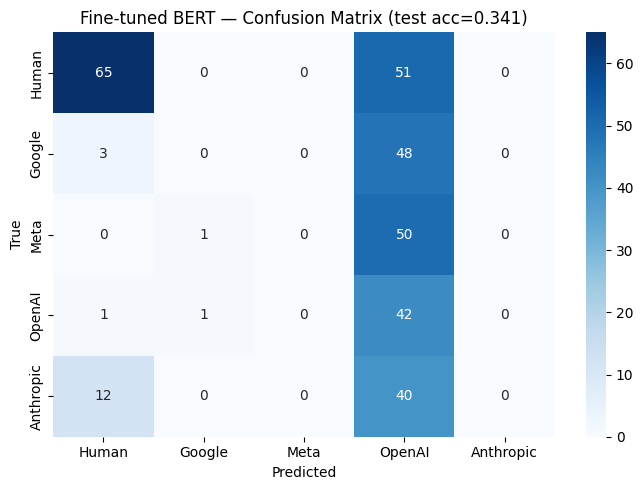

In [52]:
cm = confusion_matrix(test_labels, test_preds)
plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt="d",
            xticklabels=LABELS, yticklabels=LABELS, cmap="Blues")
plt.title(f"Fine-tuned BERT — Confusion Matrix (test acc={test_acc:.3f})")
plt.ylabel("True")
plt.xlabel("Predicted")
plt.tight_layout()
plt.show()

### B6 · Inferência em texto novo

In [53]:
def predict(text: str) -> dict:
    """Classifica um texto e devolve a label prevista com as probabilidades."""
    model.eval()
    enc = tokenizer(
        text,
        padding="max_length",
        truncation=True,
        max_length=MAX_LEN,
        return_tensors="pt",
    )
    with torch.no_grad():
        outputs = model(
            input_ids      = enc["input_ids"].to(DEVICE),
            attention_mask = enc["attention_mask"].to(DEVICE),
            #token_type_ids = enc["token_type_ids"].to(DEVICE),
        )
    probs = torch.softmax(outputs.logits, dim=1).cpu().numpy()[0]
    pred  = int(np.argmax(probs))
    return {
        "prediction" : IDX2LABEL[pred],
        "confidence" : f"{probs[pred]*100:.1f}%",
        "scores"     : {IDX2LABEL[i]: f"{p:.3f}" for i, p in enumerate(probs)},
    }

# ── Exemplos ──
exemplos = [
    "I believe that artificial intelligence has great potential to help humanity.",
    "Our new model achieves state-of-the-art results on multiple benchmarks.",
    "I went to the market this morning and bought some fresh vegetables.",
]

for texto in exemplos:
    res = predict(texto)
    print(f"Texto      : {texto[:70]}...")
    print(f"Previsão   : {res['prediction']}  (confiança: {res['confidence']})")
    print(f"Scores     : {res['scores']}")
    print()

Texto      : I believe that artificial intelligence has great potential to help hum...
Previsão   : Anthropic  (confiança: 34.2%)
Scores     : {'Human': '0.143', 'Google': '0.131', 'Meta': '0.204', 'OpenAI': '0.179', 'Anthropic': '0.342'}

Texto      : Our new model achieves state-of-the-art results on multiple benchmarks...
Previsão   : Anthropic  (confiança: 27.7%)
Scores     : {'Human': '0.241', 'Google': '0.167', 'Meta': '0.149', 'OpenAI': '0.166', 'Anthropic': '0.277'}

Texto      : I went to the market this morning and bought some fresh vegetables....
Previsão   : Anthropic  (confiança: 48.8%)
Scores     : {'Human': '0.172', 'Google': '0.098', 'Meta': '0.138', 'OpenAI': '0.104', 'Anthropic': '0.488'}



In [54]:
_, subm_acc, subm_labels, subm_preds = evaluate_loader(model, subm2_loader)

print(f"Subm2 Accuracy: {subm_acc:.4f}\n")
print(classification_report(
    subm_labels, subm_preds,
    target_names=LABELS,
    zero_division=0
))

Subm2 Accuracy: 0.3400

              precision    recall  f1-score   support

       Human       0.75      0.53      0.62        34
      Google       0.00      0.00      0.00        18
        Meta       0.00      0.00      0.00        16
      OpenAI       0.21      1.00      0.35        16
   Anthropic       0.00      0.00      0.00        16

    accuracy                           0.34       100
   macro avg       0.19      0.31      0.19       100
weighted avg       0.29      0.34      0.27       100



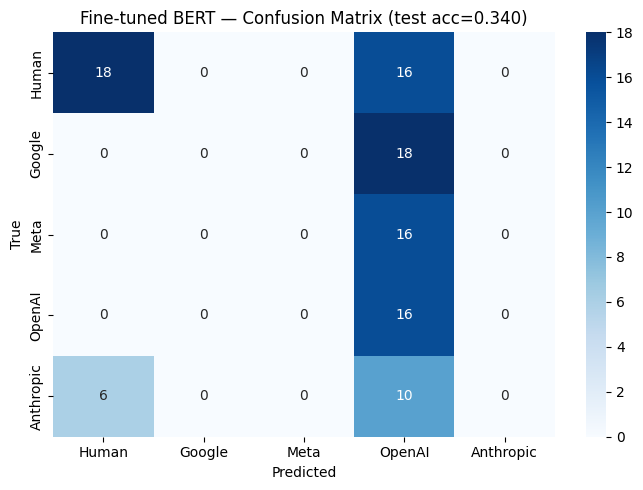

In [55]:
cm2 = confusion_matrix(subm_labels, subm_preds)
plt.figure(figsize=(7, 5))
sns.heatmap(cm2, annot=True, fmt="d",
            xticklabels=LABELS, yticklabels=LABELS, cmap="Blues")
plt.title(f"Fine-tuned BERT — Confusion Matrix (test acc={subm_acc:.3f})")
plt.ylabel("True")
plt.xlabel("Predicted")
plt.tight_layout()
plt.show()

### B7 · Guardar o modelo (opcional)

In [56]:
# Descomenta para guardar o modelo fine-tunado
model.save_pretrained("./bert-llm-author-finetuned")
tokenizer.save_pretrained("./bert-llm-author-finetuned")
# print("Modelo guardado em ./bert-llm-author-finetuned")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

('./bert-llm-author-finetuned\\tokenizer_config.json',
 './bert-llm-author-finetuned\\tokenizer.json')

distilbert -> 0.34 test, 0.34 subm2